# [실습5] 딥러닝을 활용한 양극소재 기반 배터리 특성 예측(정답)
---

## 실습 목표

- 머신러닝 분류 모델들의 원리를 이해하고 코드를 작성합니다.
- 주성분 분석을 통해 저차원 공간에서 피처가 분리되는 것을 확인합니다.
- 분류 모델들의 성능을 비교해봅니다. 각각 토이 데이터셋과 실습 데이터셋에서 검증합니다.

---

## 실습 개요

이번 실습에서는 딥러닝 모델들을 구현하고 실습 데이터에 어떻게 적용될 수 있는지 확인합니다.

---

## 1. 선형 회귀 모델의 비선형 데이터 회귀
---
먼저, 비선형 데이터에 선형 모델을 적용하면 안되는 이유를 먼저 살펴보겠습니다.

세상에 존재하는 대부분의 물질은 다양한 환경 및 요소과 복잡하게 상호작용을 합니다.

따라서, 대부분의 물리량은 비선형성을 띄게 됩니다.

우선, 선형 데이터에 선형 회귀 모델을 다시 적용해보겠습니다.

In [1]:
## 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from warnings import simplefilter
simplefilter(action='ignore', category=FutureWarning)


---
### 1.1 선형 데이터 생성
독립변수가 1개이고 선형 관계인 종속변수도 1개인 데이터를 생성합니다.

In [2]:
random_seed = 42
np.random.seed(random_seed)

data_size = 500
X = 2.5 * np.random.normal(size=data_size) + 1.5   
res = 0.2 * np.random.normal(size=data_size)
y = 0.3 * X + res

df = pd.DataFrame(
    {'X': X,
     'y': y}
)

X = df.iloc[:, :-1].values
y = df.iloc[:, 1].values

print(X.shape)
print(y.shape)

(500, 1)
(500,)


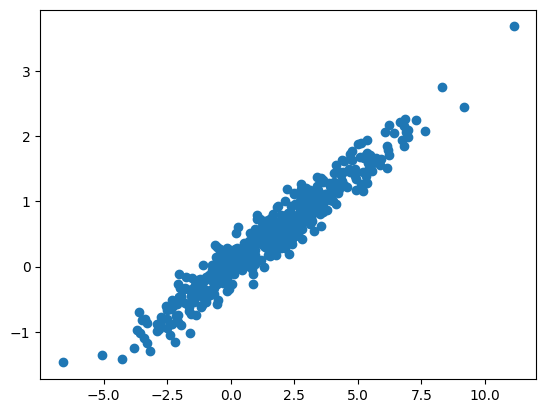

In [3]:
plt.scatter(X, y)
plt.show()

7:3 의 비율로 학습 데이터와 테스트 데이터를 구분합니다.

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3, random_state=random_seed)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(350, 1)
(150, 1)
(350,)
(150,)


---
### 1.2 선형 회귀 모델 학습
sklearn 라이브러리를 이용해 선형 회귀 모델을 학습합니다. 학습 데이터만 사용해 학습을 진행합니다.

In [5]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, Y_train)

LinearRegression()

선형 회귀 모델의 결과를 시각화합니다.

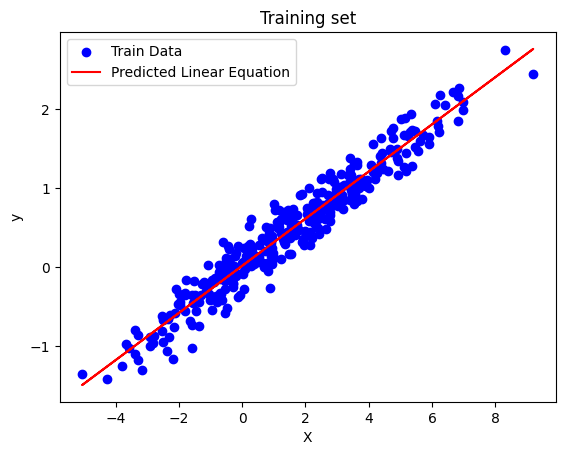

In [6]:
plt.scatter(X_train, Y_train, color='blue', label='Train Data')
plt.plot(X_train, regressor.predict(X_train), color='red', label='Predicted Linear Equation')
plt.title('Training set')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

테스트 데이터에 대한 예측 결과도 시각화합니다. 여기서 GT란 Ground Truth, 즉 정답 데이터라는 뜻입니다.

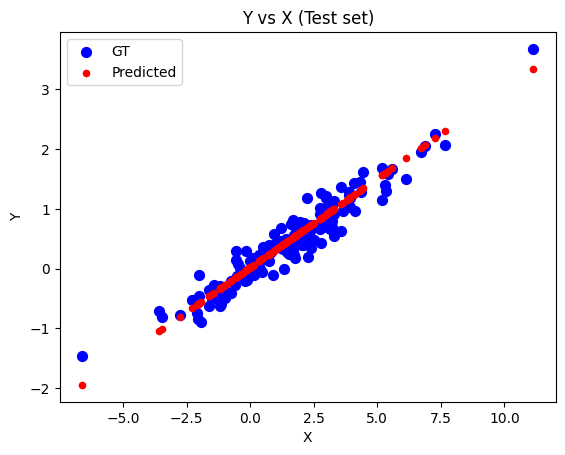

In [7]:
Y_pred = regressor.predict(X_test)
plt.scatter(X_test, Y_test, color = 'blue', s=50, label='GT')
plt.scatter(X_test, Y_pred, color = 'red', s=20, label='Predicted')
plt.title('Y vs X (Test set)')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

선형 회귀 예측이 잘 되는 것을 확인할 수 있습니다.

---
## 1.3 비선형 데이터 생성
이번에는 비선형성을 띄는 데이터를 생성해보고, 동일한 모델을 그대로 적용해보겠습니다.

In [8]:
data_size = 500
X = np.random.normal(size=data_size) + 1.0
res = 0.2 * np.random.normal(size=data_size)
y = 0.5 * np.e ** X + res

df = pd.DataFrame(
    {'X': X,
     'y': y}
)

X = df.iloc[:, :-1].values
y = df.iloc[:, 1].values

print(X.shape)
print(y.shape)

(500, 1)
(500,)


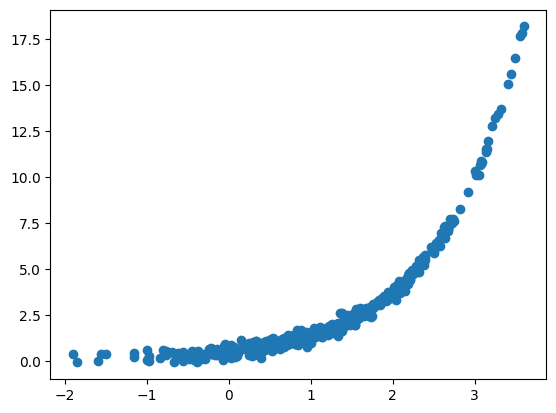

In [9]:
plt.scatter(X, y)
plt.show()

입력변수 X와 exponential 관계를 갖는 종속변수가 생성되었습니다.

7:3 의 비율로 학습 데이터와 테스트 데이터를 구분합니다.

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3, random_state=random_seed)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(350, 1)
(150, 1)
(350,)
(150,)


---
### 1.4 비선형 데이터 학습
동일한 방법으로 선형 회귀 모델을 학습합니다.

In [11]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, Y_train)

LinearRegression()

예측 결과를 시각화합니다.

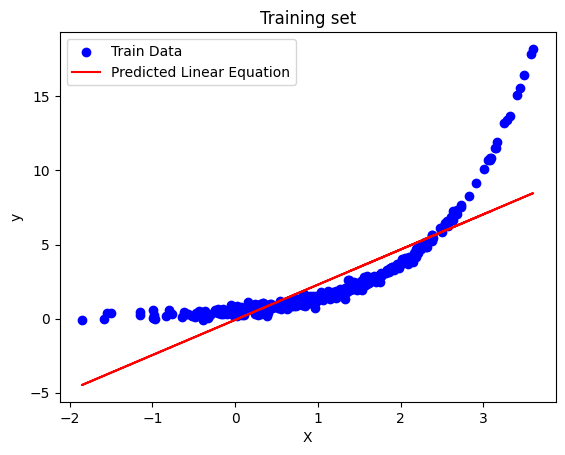

In [12]:
plt.scatter(X_train, Y_train, color='blue', label='Train Data')
plt.plot(X_train, regressor.predict(X_train), color='red', label='Predicted Linear Equation')
plt.title('Training set')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

테스트 데이터에 대한 예측 결과도 시각화합니다.

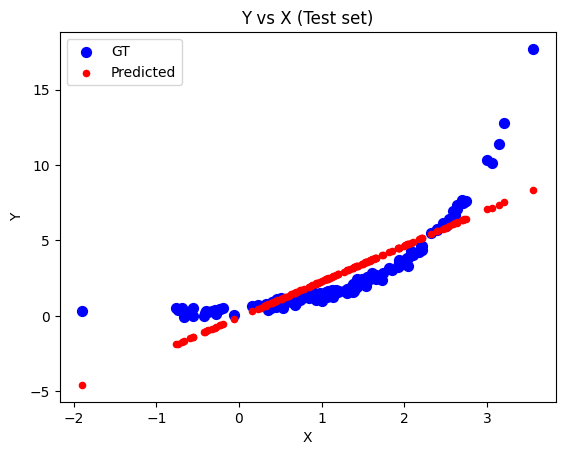

In [13]:
Y_pred = regressor.predict(X_test)
plt.scatter(X_test, Y_test, color = 'blue', s=50, label='GT')
plt.scatter(X_test, Y_pred, color = 'red', s=20, label='Predicted')
plt.title('Y vs X (Test set)')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

선형 회귀 모델은 데이터 간의 비선형 관계를 표현할 수 없습니다.

이러할 경우 오차를 최소화할 수 있는 가장 __중도적인__ 선형 관계를 찾게 됩니다.

이는 선형 모델이 비선형 데이터를 학습하게 된 경우에만 발생하는 문제가 아닙니다.

인공지능 모델의 표현력이 부족하는 모든 상황에서 동일하게 적용되는 현상입니다.

즉, 모델의 표현력을 적절하게 구성해주지 못하면, 데이터를 해석할 수 있는 능력이 부족하여 예측 결과를 신뢰할 수 없게 됩니다.

---
## 2. MLP 모델
인공신경망(Artificial Neural Network)는 대표적인 비선형 모델 중 하나입니다.

인공신경망 중 가장 간단한 형태인 MLP 모델을 실습해보겠습니다.

---
### 2.1 라이브러리 불러오기
파이썬은 가장 인공지능 친화적인 언어로 잘 알려져있습니다.

파이썬에서는 인공지능 구현을 도와주는 훌륭한 라이브러리들이 지원되기 때문입니다. 이들은 프레임워크(Framework)라는 이름으로 불리기도 합니다.

가장 대표적인 프레임워크로는 TensorFlow, PyTorch가 있습니다.

본 실습에서는 TensorFlow를 이용합니다.


In [14]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input

2023-07-26 08:47:40.033897: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-07-26 08:47:40.736892: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-07-26 08:47:45.736390: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2023-07-26 08:47:45.736973: W tensorflow/

---
### 2.2 MLP 모델 구성
입력의 크기는 입력 데이터의 크기, 출력은 정답 데이터의 크기로 설정합니다.

은닉층 2개인 간단한 모델을 구성해보겠습니다.

활성화 함수(Activation Function)은 ReLU를 이용하겠습니다.

In [15]:
print(X_train.shape)
print(Y_train.shape)
MLP_model = tf.keras.Sequential([
    Input(shape=X_train.shape[1]),
    tf.keras.layers.Dense(64, activation = 'relu'),
    tf.keras.layers.Dense(32, activation = 'relu'),
    tf.keras.layers.Dense(1)
])

(350, 1)
(350,)


2023-07-26 08:47:53.981881: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2023-07-26 08:47:53.982738: W tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: UNKNOWN ERROR (303)
2023-07-26 08:47:53.982778: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (8eae064d4b4f): /proc/driver/nvidia/version does not exist
2023-07-26 08:47:53.985036: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate com

---
### 2.3 학습 방법 설정
손실 함수는 MSE, 최적화 함수는 SGD을 이용합니다.

In [16]:
MLP_model.compile(loss = 'mse', 
                  optimizer = 'sgd'
)

---
### 2.4 MLP 모델 학습

In [17]:
history = MLP_model.fit(X_train, Y_train, epochs = 30, batch_size = 16, verbose = 2)

Epoch 1/30
22/22 - 1s - loss: 6.1430 - 932ms/epoch - 42ms/step
Epoch 2/30
22/22 - 0s - loss: 2.6857 - 48ms/epoch - 2ms/step
Epoch 3/30
22/22 - 0s - loss: 1.9706 - 44ms/epoch - 2ms/step
Epoch 4/30
22/22 - 0s - loss: 1.8454 - 38ms/epoch - 2ms/step
Epoch 5/30
22/22 - 0s - loss: 1.4732 - 36ms/epoch - 2ms/step
Epoch 6/30
22/22 - 0s - loss: 1.4451 - 39ms/epoch - 2ms/step
Epoch 7/30
22/22 - 0s - loss: 1.2035 - 34ms/epoch - 2ms/step
Epoch 8/30
22/22 - 0s - loss: 1.1080 - 37ms/epoch - 2ms/step
Epoch 9/30
22/22 - 0s - loss: 1.0841 - 32ms/epoch - 1ms/step
Epoch 10/30
22/22 - 0s - loss: 0.8069 - 37ms/epoch - 2ms/step
Epoch 11/30
22/22 - 0s - loss: 0.9569 - 35ms/epoch - 2ms/step
Epoch 12/30
22/22 - 0s - loss: 0.7422 - 36ms/epoch - 2ms/step
Epoch 13/30
22/22 - 0s - loss: 0.9766 - 33ms/epoch - 2ms/step
Epoch 14/30
22/22 - 0s - loss: 0.6904 - 31ms/epoch - 1ms/step
Epoch 15/30
22/22 - 0s - loss: 0.6717 - 32ms/epoch - 1ms/step
Epoch 16/30
22/22 - 0s - loss: 0.6042 - 30ms/epoch - 1ms/step
Epoch 17/30
22/

---
### 2.5 모델 예측


In [18]:
Y_pred = MLP_model.predict(X_test)

5/5 [==============================] - 0s 2ms/step


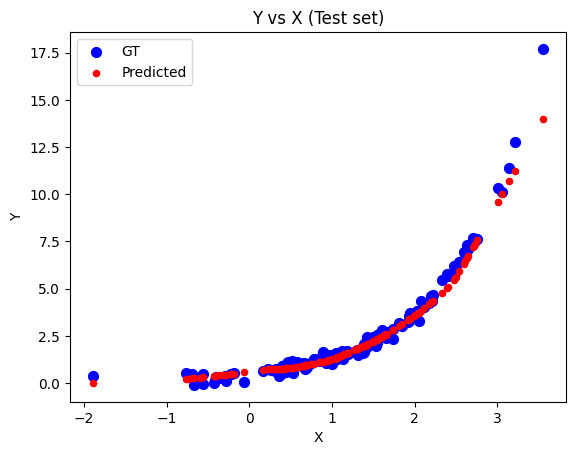

In [19]:

plt.scatter(X_test, Y_test, color = 'blue', s=50, label='GT')
plt.scatter(X_test, Y_pred, color = 'red', s=20, label='Predicted')
plt.title('Y vs X (Test set)')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

비선형 데이터를 잘 예측하는 것을 확인할 수 있습니다.

## 3. 원-핫 인코딩
---
이어서 타이타닉 토이 데이터셋을 이용해 데이터셋 전처리를 진행하겠습니다.

기존에 적용했던 전처리와 더불어, 원-핫 인코딩을 적용하는 것을 중심적으로 다뤄보겠습니다.

---
### 3.1 토이 데이터셋 불러오기
타이타닉 데이터셋을 불러옵니다.

In [20]:
df = pd.read_csv('./data/titanic_processed.csv') # df: dataframe의 줄임말
df.drop(columns = df.columns[0], axis = 1, inplace= True) # 데이터 순서를 표현하는 첫 열을 제거합니다.
display(df)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,title,gender,grade
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",Miss,0,0
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",Rare_m,1,4
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",Miss,0,0
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",Mr,1,1
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",Mrs,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1040,3,0,"Youseff, Mr. Gerious",male,45.5000,0,0,2628,7.2250,NaN,C,NaN,312.0,NaN,Mr,1,1
1041,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN,Miss,0,0
1042,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN,Mr,1,1
1043,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN,Mr,1,1


해당 승객의 생존 여부를 정답 데이터로 지정하겠습니다. 나머지 데이터를 입력 데이터로 지정합니다.

In [21]:
from sklearn.model_selection import train_test_split

X = df[['pclass', 'age', 'sibsp', 'parch', 'fare', 'gender', 'embarked']]
y = df['survived']

display(X)
display(y)


,pclass,age,sibsp,parch,fare,gender,embarked
0,1,29.0000,0,0,211.3375,0,S
1,1,0.9167,1,2,151.5500,1,S
2,1,2.0000,1,2,151.5500,0,S
3,1,30.0000,1,2,151.5500,1,S
4,1,25.0000,1,2,151.5500,0,S
...,...,...,...,...,...,...,...
1040,3,45.5000,0,0,7.2250,1,C
1041,3,14.5000,1,0,14.4542,0,C
1042,3,26.5000,0,0,7.2250,1,C
1043,3,27.0000,0,0,7.2250,1,C


0       1
1       1
2       0
3       0
4       0
       ..
1040    0
1041    0
1042    0
1043    0
1044    0
Name: survived, Length: 1045, dtype: int64

---
### 3.2 원-핫 인코딩(One-Hot Encoding)
범주형 데이터에 대해 원-핫 인코딩을 적용해보겠습니다.

우선 연속형 데이터에 해당하는 데이터들을 식별해보겠습니다.

1. age는 나이를 숫자로 나타낸 데이터이기 때문에 원-핫 인코딩이 불필요합니다. 
2. sibsp는 동승한 자매/배우자의 수 입니다. 따라서 연속된 숫자를 표현하고 있습니다.
3. parch는 동승한 부모/자식의 수로 동일합니다.
4. fare는 승객 요금으로 연속된 숫자입니다.

그와 반대로, pclass의 값은 1등석, 2등석, 3등석을 의미하므로 범주형 데이터에 속합니다.

In [22]:
dummies = pd.get_dummies(X['pclass']).astype('int')
dummies.columns = ['1class', '2class', '3class']
display(dummies)

,1class,2class,3class
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
1040,0,0,1
1041,0,0,1
1042,0,0,1
1043,0,0,1


In [23]:
X.drop('pclass', axis=1, inplace=True)
X = X.join(dummies)
display(X)

/tmp/ipykernel_66/1992532754.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.drop('pclass', axis=1, inplace=True)


,age,sibsp,parch,fare,gender,embarked,1class,2class,3class
0,29.0000,0,0,211.3375,0,S,1,0,0
1,0.9167,1,2,151.5500,1,S,1,0,0
2,2.0000,1,2,151.5500,0,S,1,0,0
3,30.0000,1,2,151.5500,1,S,1,0,0
4,25.0000,1,2,151.5500,0,S,1,0,0
...,...,...,...,...,...,...,...,...,...
1040,45.5000,0,0,7.2250,1,C,0,0,1
1041,14.5000,1,0,14.4542,0,C,0,0,1
1042,26.5000,0,0,7.2250,1,C,0,0,1
1043,27.0000,0,0,7.2250,1,C,0,0,1


gender는 남성과 여성으로 분류되는 데이터입니다.

In [24]:
dummies = pd.get_dummies(X['gender']).astype('int')
dummies.columns = ['female', 'male']
display(dummies)

,female,male
0,1,0
1,0,1
2,1,0
3,0,1
4,1,0
...,...,...
1040,0,1
1041,1,0
1042,0,1
1043,0,1


In [25]:
X.drop('gender', axis=1, inplace=True)
X = X.join(dummies)
display(X)

,age,sibsp,parch,fare,embarked,1class,2class,3class,female,male
0,29.0000,0,0,211.3375,S,1,0,0,1,0
1,0.9167,1,2,151.5500,S,1,0,0,0,1
2,2.0000,1,2,151.5500,S,1,0,0,1,0
3,30.0000,1,2,151.5500,S,1,0,0,0,1
4,25.0000,1,2,151.5500,S,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
1040,45.5000,0,0,7.2250,C,0,0,1,0,1
1041,14.5000,1,0,14.4542,C,0,0,1,1,0
1042,26.5000,0,0,7.2250,C,0,0,1,0,1
1043,27.0000,0,0,7.2250,C,0,0,1,0,1


embarked는 탑승지를 의미합니다. S는 사우샘프턴, C는 셰르부르, Q는 퀸즈타운을 나타냅니다.

In [26]:
dummies = pd.get_dummies(X['embarked']).astype('int')
dummies.columns = ['S', 'C', 'Q']
display(dummies)

,S,C,Q
0,0,0,1
1,0,0,1
2,0,0,1
3,0,0,1
4,0,0,1
...,...,...,...
1040,1,0,0
1041,1,0,0
1042,1,0,0
1043,1,0,0


In [27]:
X.drop('embarked', axis=1, inplace=True)
X = X.join(dummies)
display(X)

,age,sibsp,parch,fare,1class,2class,3class,female,male,S,C,Q
0,29.0000,0,0,211.3375,1,0,0,1,0,0,0,1
1,0.9167,1,2,151.5500,1,0,0,0,1,0,0,1
2,2.0000,1,2,151.5500,1,0,0,1,0,0,0,1
3,30.0000,1,2,151.5500,1,0,0,0,1,0,0,1
4,25.0000,1,2,151.5500,1,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1040,45.5000,0,0,7.2250,0,0,1,0,1,1,0,0
1041,14.5000,1,0,14.4542,0,0,1,1,0,1,0,0
1042,26.5000,0,0,7.2250,0,0,1,0,1,1,0,0
1043,27.0000,0,0,7.2250,0,0,1,0,1,1,0,0


---
### 3.3 정규화 & 표준화
원-핫 인코딩이 완료된 토이 데이터셋에 정규화와 표준화를 진행합니다. 

In [28]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
std_scaler.fit(X)
scaled_X = std_scaler.transform(X)
X = pd.DataFrame(scaled_X, columns=X.columns, index=list(X.index.values))
display(X)

,age,sibsp,parch,fare,1class,2class,3class,female,male,S,C,Q
0,-0.059228,-0.551897,-0.501462,3.135243,1.636941,-0.576982,-0.957826,1.301268,-1.301268,-0.504482,-0.224168,0.581402
1,-2.011855,0.544553,1.880484,2.061972,1.636941,-0.576982,-0.957826,-0.768481,0.768481,-0.504482,-0.224168,0.581402
2,-1.936534,0.544553,1.880484,2.061972,1.636941,-0.576982,-0.957826,1.301268,-1.301268,-0.504482,-0.224168,0.581402
3,0.010302,0.544553,1.880484,2.061972,1.636941,-0.576982,-0.957826,-0.768481,0.768481,-0.504482,-0.224168,0.581402
4,-0.337347,0.544553,1.880484,2.061972,1.636941,-0.576982,-0.957826,1.301268,-1.301268,-0.504482,-0.224168,0.581402
...,...,...,...,...,...,...,...,...,...,...,...,...
1040,1.088014,-0.551897,-0.501462,-0.528869,-0.610895,-0.576982,1.044031,-0.768481,0.768481,1.982232,-0.224168,-1.719981
1041,-1.067411,0.544553,-0.501462,-0.399094,-0.610895,-0.576982,1.044031,1.301268,-1.301268,1.982232,-0.224168,-1.719981
1042,-0.233052,-0.551897,-0.501462,-0.528869,-0.610895,-0.576982,1.044031,-0.768481,0.768481,1.982232,-0.224168,-1.719981
1043,-0.198288,-0.551897,-0.501462,-0.528869,-0.610895,-0.576982,1.044031,-0.768481,0.768481,1.982232,-0.224168,-1.719981


---
### 3.4 학습 & 테스트 데이터 구분

In [29]:
random_seed = 42
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size = 0.3, random_state = random_seed)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(731, 12)
(314, 12)
(731,)
(314,)


---
## 4. 학습률에 따른 성능
인공신경망 모델을 만든 후, 가장 먼저 튜닝해야 할 파라미터는 학습률입니다.

다른 설정값에 따라 최적의 학습률은 바뀌게 되지만, 최소한 적당한 학습률의 범위가 어느정도인지는 파악을 해야합니다.

---
### 4.1 MLP 모델 구성
우선 MLP 모델을 만듭니다. 보다 복잡한 데이터이기 때문에 은닉층을 3개로 구성해보겠습니다.

In [30]:
MLP_model = tf.keras.Sequential([
    Input(shape=X_train.shape[1]),
    tf.keras.layers.Dense(64, activation = 'relu'),
    tf.keras.layers.Dense(64, activation = 'relu'),
    tf.keras.layers.Dense(32, activation = 'relu'),
    tf.keras.layers.Dense(1)
])

---
### 4.2 학습률 변경
학습률에 따른 모델 학습 경과를 시각화해보겠습니다. 

In [31]:
lr = 0.1
MLP_model.compile(loss = 'mse',
              optimizer = tf.keras.optimizers.SGD(learning_rate = lr),
)

In [32]:
history_dict = {}

In [33]:
history = MLP_model.fit(X_train, Y_train, epochs = 30, batch_size = 16, verbose = 2)
history_dict['lr={}'.format(lr)] = history

Epoch 1/30
46/46 - 1s - loss: 0.1764 - 557ms/epoch - 12ms/step
Epoch 2/30
46/46 - 0s - loss: 0.1393 - 67ms/epoch - 1ms/step
Epoch 3/30
46/46 - 0s - loss: 0.1297 - 76ms/epoch - 2ms/step
Epoch 4/30
46/46 - 0s - loss: 0.1256 - 67ms/epoch - 1ms/step
Epoch 5/30
46/46 - 0s - loss: 0.1224 - 71ms/epoch - 2ms/step
Epoch 6/30
46/46 - 0s - loss: 0.1237 - 75ms/epoch - 2ms/step
Epoch 7/30
46/46 - 0s - loss: 0.1208 - 70ms/epoch - 2ms/step
Epoch 8/30
46/46 - 0s - loss: 0.1181 - 70ms/epoch - 2ms/step
Epoch 9/30
46/46 - 0s - loss: 0.1153 - 67ms/epoch - 1ms/step
Epoch 10/30
46/46 - 0s - loss: 0.1187 - 67ms/epoch - 1ms/step
Epoch 11/30
46/46 - 0s - loss: 0.1174 - 66ms/epoch - 1ms/step
Epoch 12/30
46/46 - 0s - loss: 0.1156 - 70ms/epoch - 2ms/step
Epoch 13/30
46/46 - 0s - loss: 0.1151 - 65ms/epoch - 1ms/step
Epoch 14/30
46/46 - 0s - loss: 0.1148 - 63ms/epoch - 1ms/step
Epoch 15/30
46/46 - 0s - loss: 0.1146 - 69ms/epoch - 2ms/step
Epoch 16/30
46/46 - 0s - loss: 0.1148 - 66ms/epoch - 1ms/step
Epoch 17/30
46/

In [34]:
lr = 0.01
MLP_model.compile(loss = 'mse',
              optimizer = tf.keras.optimizers.SGD(learning_rate = lr),
)
history = MLP_model.fit(X_train, Y_train, epochs = 30, batch_size = 16, verbose = 2)
history_dict['lr={}'.format(lr)] = history

Epoch 1/30
46/46 - 1s - loss: 0.0996 - 543ms/epoch - 12ms/step
Epoch 2/30
46/46 - 0s - loss: 0.0986 - 70ms/epoch - 2ms/step
Epoch 3/30
46/46 - 0s - loss: 0.0982 - 68ms/epoch - 1ms/step
Epoch 4/30
46/46 - 0s - loss: 0.0980 - 70ms/epoch - 2ms/step
Epoch 5/30
46/46 - 0s - loss: 0.0979 - 70ms/epoch - 2ms/step
Epoch 6/30
46/46 - 0s - loss: 0.0977 - 66ms/epoch - 1ms/step
Epoch 7/30
46/46 - 0s - loss: 0.0975 - 71ms/epoch - 2ms/step
Epoch 8/30
46/46 - 0s - loss: 0.0975 - 69ms/epoch - 1ms/step
Epoch 9/30
46/46 - 0s - loss: 0.0973 - 69ms/epoch - 2ms/step
Epoch 10/30
46/46 - 0s - loss: 0.0971 - 69ms/epoch - 2ms/step
Epoch 11/30
46/46 - 0s - loss: 0.0972 - 68ms/epoch - 1ms/step
Epoch 12/30
46/46 - 0s - loss: 0.0972 - 81ms/epoch - 2ms/step
Epoch 13/30
46/46 - 0s - loss: 0.0970 - 67ms/epoch - 1ms/step
Epoch 14/30
46/46 - 0s - loss: 0.0970 - 73ms/epoch - 2ms/step
Epoch 15/30
46/46 - 0s - loss: 0.0969 - 66ms/epoch - 1ms/step
Epoch 16/30
46/46 - 0s - loss: 0.0966 - 70ms/epoch - 2ms/step
Epoch 17/30
46/

In [35]:
lr = 0.001
MLP_model.compile(loss = 'mse',
              optimizer = tf.keras.optimizers.SGD(learning_rate = lr),
)
history = MLP_model.fit(X_train, Y_train, epochs = 30, batch_size = 16, verbose = 2)
history_dict['lr={}'.format(lr)] = history

Epoch 1/30
46/46 - 1s - loss: 0.0949 - 551ms/epoch - 12ms/step
Epoch 2/30
46/46 - 0s - loss: 0.0949 - 68ms/epoch - 1ms/step
Epoch 3/30
46/46 - 0s - loss: 0.0949 - 69ms/epoch - 1ms/step
Epoch 4/30
46/46 - 0s - loss: 0.0948 - 71ms/epoch - 2ms/step
Epoch 5/30
46/46 - 0s - loss: 0.0948 - 71ms/epoch - 2ms/step
Epoch 6/30
46/46 - 0s - loss: 0.0948 - 79ms/epoch - 2ms/step
Epoch 7/30
46/46 - 0s - loss: 0.0948 - 69ms/epoch - 1ms/step
Epoch 8/30
46/46 - 0s - loss: 0.0948 - 65ms/epoch - 1ms/step
Epoch 9/30
46/46 - 0s - loss: 0.0948 - 72ms/epoch - 2ms/step
Epoch 10/30
46/46 - 0s - loss: 0.0948 - 69ms/epoch - 2ms/step
Epoch 11/30
46/46 - 0s - loss: 0.0948 - 65ms/epoch - 1ms/step
Epoch 12/30
46/46 - 0s - loss: 0.0948 - 67ms/epoch - 1ms/step
Epoch 13/30
46/46 - 0s - loss: 0.0947 - 71ms/epoch - 2ms/step
Epoch 14/30
46/46 - 0s - loss: 0.0947 - 65ms/epoch - 1ms/step
Epoch 15/30
46/46 - 0s - loss: 0.0947 - 69ms/epoch - 1ms/step
Epoch 16/30
46/46 - 0s - loss: 0.0948 - 69ms/epoch - 1ms/step
Epoch 17/30
46/

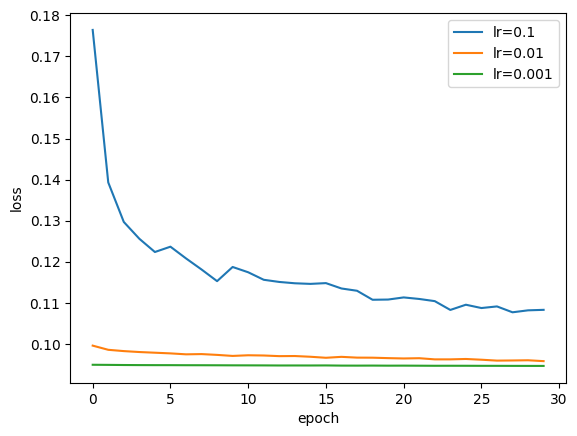

In [36]:
for lr_label, hist in history_dict.items():
    plt.plot(hist.epoch, hist.history['loss'], label=lr_label)
#plt.ylim(0.09, 0.15)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

학습률이 0.1일 때는 학습이 불균일하게 이뤄지는 것을 확인할 수 있습니다.

학습률 0.01과 0.001은 안정적으로 이뤄지고 있습니다.

따라서 현재 데이터셋에서 안정적인 학습률은 0.01을 초과하지 않는다고 여길 수 있습니다.

이후 실습에서는 0.01 을 사용하겠습니다.

---
## 5. 활성화 함수에 따른 성능
대표적인 활성화 함수들을 사용하며 성능을 확인해보겠습니다.

---
### 5.1 분류 모델 성능 지표

정확한 성능 비교를 위해 분류 모델 성능 지표 함수를 정의합니다.

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluation(prediction, Y_test, model_name="모델 이름"):
    print(model_name, "의 정답률은 %.2f%% 입니다." % (accuracy_score(prediction, Y_test) * 100))
    print(model_name, "의 정밀도는 %.2f 입니다." % precision_score(Y_test, prediction))
    print(model_name, "의 재현율은 %.2f 입니다." % recall_score(Y_test, prediction))
    print(model_name, "의 F1 점수는 %.2f 입니다." % f1_score(Y_test, prediction))
    print(model_name, "의 ROC-AUC 점수는 %.2f 입니다." % roc_auc_score(Y_test, prediction))

---
### 5.2 시그모이드

시그모이드 활성화 함수를 사용하는 모델을 구성합니다.

In [38]:
act = 'sigmoid'

model = tf.keras.Sequential([
    Input(shape=X_train.shape[1]),
    tf.keras.layers.Dense(64, activation = act),
    tf.keras.layers.Dense(64, activation = act),
    tf.keras.layers.Dense(32, activation = act),
    tf.keras.layers.Dense(1)
])

lr = 0.01
model.compile(loss = 'mse',
              optimizer = tf.keras.optimizers.SGD(learning_rate = lr),
)

In [39]:
history = model.fit(X_train, Y_train, epochs = 30, batch_size = 16, verbose = 2)


Epoch 1/30
46/46 - 1s - loss: 0.3609 - 568ms/epoch - 12ms/step
Epoch 2/30
46/46 - 0s - loss: 0.2465 - 72ms/epoch - 2ms/step
Epoch 3/30
46/46 - 0s - loss: 0.2451 - 67ms/epoch - 1ms/step
Epoch 4/30
46/46 - 0s - loss: 0.2440 - 70ms/epoch - 2ms/step
Epoch 5/30
46/46 - 0s - loss: 0.2435 - 74ms/epoch - 2ms/step
Epoch 6/30
46/46 - 0s - loss: 0.2410 - 69ms/epoch - 1ms/step
Epoch 7/30
46/46 - 0s - loss: 0.2398 - 65ms/epoch - 1ms/step
Epoch 8/30
46/46 - 0s - loss: 0.2400 - 64ms/epoch - 1ms/step
Epoch 9/30
46/46 - 0s - loss: 0.2400 - 66ms/epoch - 1ms/step
Epoch 10/30
46/46 - 0s - loss: 0.2376 - 70ms/epoch - 2ms/step
Epoch 11/30
46/46 - 0s - loss: 0.2380 - 65ms/epoch - 1ms/step
Epoch 12/30
46/46 - 0s - loss: 0.2373 - 72ms/epoch - 2ms/step
Epoch 13/30
46/46 - 0s - loss: 0.2386 - 66ms/epoch - 1ms/step
Epoch 14/30
46/46 - 0s - loss: 0.2360 - 68ms/epoch - 1ms/step
Epoch 15/30
46/46 - 0s - loss: 0.2356 - 67ms/epoch - 1ms/step
Epoch 16/30
46/46 - 0s - loss: 0.2343 - 69ms/epoch - 2ms/step
Epoch 17/30
46/

In [40]:
pred = model.predict(X_test)
sigmoid_pred = np.where(pred > 0.5, 1, 0) # 예측값이 0.5보다 크면 1, 작으면 0


10/10 [==============================] - 0s 2ms/step


In [41]:
evaluation(sigmoid_pred, Y_test, model_name="시그모이드")

시그모이드 의 정답률은 62.42% 입니다.
시그모이드 의 정밀도는 0.86 입니다.
시그모이드 의 재현율은 0.18 입니다.
시그모이드 의 F1 점수는 0.30 입니다.
시그모이드 의 ROC-AUC 점수는 0.58 입니다.


---
### 5.3 하이퍼볼릭 탄젠트

하이퍼볼릭 탄젠트 활성화 함수를 사용하는 모델을 구성합니다.

In [42]:
act = 'tanh'

model = tf.keras.Sequential([
    Input(shape=X_train.shape[1]),
    tf.keras.layers.Dense(64, activation = act),
    tf.keras.layers.Dense(64, activation = act),
    tf.keras.layers.Dense(32, activation = act),
    tf.keras.layers.Dense(1)
])

lr = 0.01
model.compile(loss = 'mse',
              optimizer = tf.keras.optimizers.SGD(learning_rate = lr),
)

In [43]:
history = model.fit(X_train, Y_train, epochs = 30, batch_size = 16, verbose = 2)


Epoch 1/30
46/46 - 1s - loss: 0.2026 - 551ms/epoch - 12ms/step
Epoch 2/30
46/46 - 0s - loss: 0.1555 - 74ms/epoch - 2ms/step
Epoch 3/30
46/46 - 0s - loss: 0.1509 - 69ms/epoch - 2ms/step
Epoch 4/30
46/46 - 0s - loss: 0.1470 - 66ms/epoch - 1ms/step
Epoch 5/30
46/46 - 0s - loss: 0.1426 - 66ms/epoch - 1ms/step
Epoch 6/30
46/46 - 0s - loss: 0.1408 - 68ms/epoch - 1ms/step
Epoch 7/30
46/46 - 0s - loss: 0.1418 - 68ms/epoch - 1ms/step
Epoch 8/30
46/46 - 0s - loss: 0.1384 - 69ms/epoch - 2ms/step
Epoch 9/30
46/46 - 0s - loss: 0.1369 - 67ms/epoch - 1ms/step
Epoch 10/30
46/46 - 0s - loss: 0.1372 - 65ms/epoch - 1ms/step
Epoch 11/30
46/46 - 0s - loss: 0.1358 - 69ms/epoch - 2ms/step
Epoch 12/30
46/46 - 0s - loss: 0.1351 - 67ms/epoch - 1ms/step
Epoch 13/30
46/46 - 0s - loss: 0.1351 - 64ms/epoch - 1ms/step
Epoch 14/30
46/46 - 0s - loss: 0.1335 - 68ms/epoch - 1ms/step
Epoch 15/30
46/46 - 0s - loss: 0.1324 - 72ms/epoch - 2ms/step
Epoch 16/30
46/46 - 0s - loss: 0.1326 - 69ms/epoch - 1ms/step
Epoch 17/30
46/

In [44]:
pred = model.predict(X_test)
tanh_pred = np.where(pred > 0.5, 1, 0) # 예측값이 0.5보다 크면 1, 작으면 0

10/10 [==============================] - 0s 2ms/step


In [45]:
evaluation(tanh_pred, Y_test, model_name="하이퍼볼릭 탄젠트")

하이퍼볼릭 탄젠트 의 정답률은 76.43% 입니다.
하이퍼볼릭 탄젠트 의 정밀도는 0.89 입니다.
하이퍼볼릭 탄젠트 의 재현율은 0.53 입니다.
하이퍼볼릭 탄젠트 의 F1 점수는 0.67 입니다.
하이퍼볼릭 탄젠트 의 ROC-AUC 점수는 0.74 입니다.


---
### 5.4 ReLU

ReLU 활성화 함수를 사용하는 모델을 구성합니다.

In [46]:
act = 'relu'

model = tf.keras.Sequential([
    Input(shape=X_train.shape[1]),
    tf.keras.layers.Dense(64, activation = act),
    tf.keras.layers.Dense(64, activation = act),
    tf.keras.layers.Dense(32, activation = act),
    tf.keras.layers.Dense(1)
])

lr = 0.01
model.compile(loss = 'mse',
              optimizer = tf.keras.optimizers.SGD(learning_rate = lr),
)

In [47]:
history = model.fit(X_train, Y_train, epochs = 30, batch_size = 16, verbose = 2)


Epoch 1/30
46/46 - 1s - loss: 0.2249 - 816ms/epoch - 18ms/step
Epoch 2/30
46/46 - 0s - loss: 0.1559 - 68ms/epoch - 1ms/step
Epoch 3/30
46/46 - 0s - loss: 0.1434 - 66ms/epoch - 1ms/step
Epoch 4/30
46/46 - 0s - loss: 0.1378 - 66ms/epoch - 1ms/step
Epoch 5/30
46/46 - 0s - loss: 0.1342 - 68ms/epoch - 1ms/step
Epoch 6/30
46/46 - 0s - loss: 0.1325 - 72ms/epoch - 2ms/step
Epoch 7/30
46/46 - 0s - loss: 0.1310 - 66ms/epoch - 1ms/step
Epoch 8/30
46/46 - 0s - loss: 0.1287 - 65ms/epoch - 1ms/step
Epoch 9/30
46/46 - 0s - loss: 0.1271 - 70ms/epoch - 2ms/step
Epoch 10/30
46/46 - 0s - loss: 0.1258 - 65ms/epoch - 1ms/step
Epoch 11/30
46/46 - 0s - loss: 0.1247 - 64ms/epoch - 1ms/step
Epoch 12/30
46/46 - 0s - loss: 0.1236 - 64ms/epoch - 1ms/step
Epoch 13/30
46/46 - 0s - loss: 0.1230 - 68ms/epoch - 1ms/step
Epoch 14/30
46/46 - 0s - loss: 0.1224 - 68ms/epoch - 1ms/step
Epoch 15/30
46/46 - 0s - loss: 0.1213 - 67ms/epoch - 1ms/step
Epoch 16/30
46/46 - 0s - loss: 0.1220 - 65ms/epoch - 1ms/step
Epoch 17/30
46/

In [48]:
pred = model.predict(X_test)
relu_pred = np.where(pred > 0.5, 1, 0) # 예측값이 0.5보다 크면 1, 작으면 0

10/10 [==============================] - 0s 2ms/step


In [49]:
evaluation(relu_pred, Y_test, model_name="ReLU")

ReLU 의 정답률은 76.11% 입니다.
ReLU 의 정밀도는 0.81 입니다.
ReLU 의 재현율은 0.60 입니다.
ReLU 의 F1 점수는 0.69 입니다.
ReLU 의 ROC-AUC 점수는 0.75 입니다.


---
### 5.5 활성화 함수 성능 비교

AUC-ROC 점수로 활성화 함수 사이의 성능을 비교해보겠습니다.

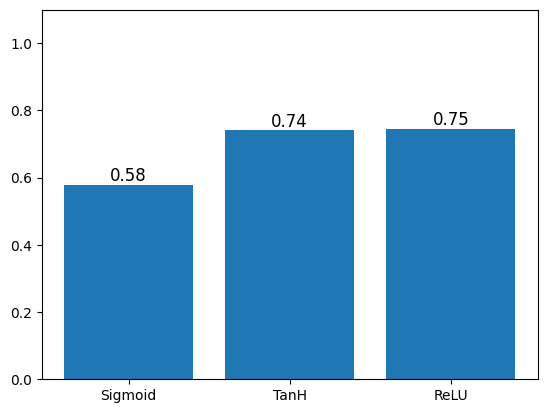

In [50]:
model_list = ['Sigmoid', 'TanH', 'ReLU']
result_list = [roc_auc_score(Y_test, sigmoid_pred, multi_class='ovr'),
               roc_auc_score(Y_test, tanh_pred, multi_class='ovr'),
               roc_auc_score(Y_test, relu_pred, multi_class='ovr')
              ] 

bar = plt.bar(model_list, result_list)
for rect in bar:
    height = rect.get_height()
    plt.text(rect.get_x() + rect.get_width()/2.0, height, '%.2f' % height, ha='center', va='bottom', size = 12)
plt.ylim(0, 1.1)
plt.show()   

ReLU 활성화 함수가 성능이 가장 좋은 것으로 나왔습니다.

ReLU는 대부분 상황에서 잘 작동하는 활성화 함수로 알려져있습니다.

---
## 6. 옵티마이저(Optimizer)
최적화 함수에 해당하는 옵티마이저를 변경하며 성능을 확인해보겠습니다.
---
### 6.1 SGD
SGD를 이용해 최적화를 진행해보겠습니다.

In [51]:
act = 'relu'

model = tf.keras.Sequential([
    Input(shape=X_train.shape[1]),
    tf.keras.layers.Dense(64, activation = act),
    tf.keras.layers.Dense(64, activation = act),
    tf.keras.layers.Dense(32, activation = act),
    tf.keras.layers.Dense(1)
])

In [52]:
lr = 0.01
model.compile(loss = 'mse',
              optimizer = tf.keras.optimizers.SGD(learning_rate = lr),
)

In [53]:
history = model.fit(X_train, Y_train, epochs = 30, batch_size = 16, verbose = 2)
pred = model.predict(X_test)
sgd_pred = np.where(pred > 0.5, 1, 0) # 예측값이 0.5보다 크면 1, 작으면 0

Epoch 1/30
46/46 - 1s - loss: 0.2308 - 539ms/epoch - 12ms/step
Epoch 2/30
46/46 - 0s - loss: 0.1679 - 74ms/epoch - 2ms/step
Epoch 3/30
46/46 - 0s - loss: 0.1513 - 69ms/epoch - 2ms/step
Epoch 4/30
46/46 - 0s - loss: 0.1422 - 72ms/epoch - 2ms/step
Epoch 5/30
46/46 - 0s - loss: 0.1355 - 69ms/epoch - 2ms/step
Epoch 6/30
46/46 - 0s - loss: 0.1319 - 66ms/epoch - 1ms/step
Epoch 7/30
46/46 - 0s - loss: 0.1292 - 72ms/epoch - 2ms/step
Epoch 8/30
46/46 - 0s - loss: 0.1275 - 77ms/epoch - 2ms/step
Epoch 9/30
46/46 - 0s - loss: 0.1253 - 67ms/epoch - 1ms/step
Epoch 10/30
46/46 - 0s - loss: 0.1247 - 71ms/epoch - 2ms/step
Epoch 11/30
46/46 - 0s - loss: 0.1240 - 78ms/epoch - 2ms/step
Epoch 12/30
46/46 - 0s - loss: 0.1224 - 71ms/epoch - 2ms/step
Epoch 13/30
46/46 - 0s - loss: 0.1218 - 73ms/epoch - 2ms/step
Epoch 14/30
46/46 - 0s - loss: 0.1207 - 72ms/epoch - 2ms/step
Epoch 15/30
46/46 - 0s - loss: 0.1196 - 72ms/epoch - 2ms/step
Epoch 16/30
46/46 - 0s - loss: 0.1197 - 69ms/epoch - 1ms/step
Epoch 17/30
46/

In [54]:
evaluation(sgd_pred, Y_test, model_name="SGD")

SGD 의 정답률은 75.80% 입니다.
SGD 의 정밀도는 0.81 입니다.
SGD 의 재현율은 0.60 입니다.
SGD 의 F1 점수는 0.69 입니다.
SGD 의 ROC-AUC 점수는 0.74 입니다.


---
### 6.2 AdaGrad
AdaGrad를 이용해 최적화를 진행해보겠습니다.

In [55]:
lr = 0.01
model.compile(loss = 'mse',
              optimizer = tf.keras.optimizers.Adagrad(learning_rate = lr),
)

In [56]:
history = model.fit(X_train, Y_train, epochs = 30, batch_size = 16, verbose = 2)
pred = model.predict(X_test)
adagrad_pred = np.where(pred > 0.5, 1, 0) # 예측값이 0.5보다 크면 1, 작으면 0

Epoch 1/30
46/46 - 1s - loss: 0.1165 - 569ms/epoch - 12ms/step
Epoch 2/30
46/46 - 0s - loss: 0.1161 - 69ms/epoch - 2ms/step
Epoch 3/30
46/46 - 0s - loss: 0.1152 - 71ms/epoch - 2ms/step
Epoch 4/30
46/46 - 0s - loss: 0.1146 - 72ms/epoch - 2ms/step
Epoch 5/30
46/46 - 0s - loss: 0.1137 - 70ms/epoch - 2ms/step
Epoch 6/30
46/46 - 0s - loss: 0.1131 - 69ms/epoch - 1ms/step
Epoch 7/30
46/46 - 0s - loss: 0.1127 - 67ms/epoch - 1ms/step
Epoch 8/30
46/46 - 0s - loss: 0.1116 - 77ms/epoch - 2ms/step
Epoch 9/30
46/46 - 0s - loss: 0.1112 - 70ms/epoch - 2ms/step
Epoch 10/30
46/46 - 0s - loss: 0.1107 - 69ms/epoch - 1ms/step
Epoch 11/30
46/46 - 0s - loss: 0.1105 - 70ms/epoch - 2ms/step
Epoch 12/30
46/46 - 0s - loss: 0.1099 - 65ms/epoch - 1ms/step
Epoch 13/30
46/46 - 0s - loss: 0.1094 - 73ms/epoch - 2ms/step
Epoch 14/30
46/46 - 0s - loss: 0.1089 - 68ms/epoch - 1ms/step
Epoch 15/30
46/46 - 0s - loss: 0.1088 - 63ms/epoch - 1ms/step
Epoch 16/30
46/46 - 0s - loss: 0.1084 - 68ms/epoch - 1ms/step
Epoch 17/30
46/

In [57]:
evaluation(adagrad_pred, Y_test, model_name="AdaGrad")

AdaGrad 의 정답률은 77.39% 입니다.
AdaGrad 의 정밀도는 0.80 입니다.
AdaGrad 의 재현율은 0.65 입니다.
AdaGrad 의 F1 점수는 0.72 입니다.
AdaGrad 의 ROC-AUC 점수는 0.76 입니다.


---
### 6.3 RMSprop
RMSprop를 이용해 최적화를 진행해보겠습니다.

In [58]:
lr = 0.01
model.compile(loss = 'mse',
              optimizer = tf.keras.optimizers.RMSprop(learning_rate = lr),
)

In [59]:
history = model.fit(X_train, Y_train, epochs = 30, batch_size = 16, verbose = 2)
pred = model.predict(X_test)
rmsprop_pred = np.where(pred > 0.5, 1, 0) # 예측값이 0.5보다 크면 1, 작으면 0

Epoch 1/30
46/46 - 1s - loss: 0.1956 - 651ms/epoch - 14ms/step
Epoch 2/30
46/46 - 0s - loss: 0.1460 - 70ms/epoch - 2ms/step
Epoch 3/30
46/46 - 0s - loss: 0.1405 - 68ms/epoch - 1ms/step
Epoch 4/30
46/46 - 0s - loss: 0.1363 - 70ms/epoch - 2ms/step
Epoch 5/30
46/46 - 0s - loss: 0.1307 - 72ms/epoch - 2ms/step
Epoch 6/30
46/46 - 0s - loss: 0.1286 - 69ms/epoch - 1ms/step
Epoch 7/30
46/46 - 0s - loss: 0.1236 - 71ms/epoch - 2ms/step
Epoch 8/30
46/46 - 0s - loss: 0.1276 - 68ms/epoch - 1ms/step
Epoch 9/30
46/46 - 0s - loss: 0.1254 - 67ms/epoch - 1ms/step
Epoch 10/30
46/46 - 0s - loss: 0.1249 - 69ms/epoch - 1ms/step
Epoch 11/30
46/46 - 0s - loss: 0.1235 - 72ms/epoch - 2ms/step
Epoch 12/30
46/46 - 0s - loss: 0.1244 - 70ms/epoch - 2ms/step
Epoch 13/30
46/46 - 0s - loss: 0.1233 - 73ms/epoch - 2ms/step
Epoch 14/30
46/46 - 0s - loss: 0.1242 - 70ms/epoch - 2ms/step
Epoch 15/30
46/46 - 0s - loss: 0.1219 - 71ms/epoch - 2ms/step
Epoch 16/30
46/46 - 0s - loss: 0.1235 - 72ms/epoch - 2ms/step
Epoch 17/30
46/

In [60]:
evaluation(rmsprop_pred, Y_test, model_name="RMSProp")

RMSProp 의 정답률은 76.43% 입니다.
RMSProp 의 정밀도는 0.78 입니다.
RMSProp 의 재현율은 0.65 입니다.
RMSProp 의 F1 점수는 0.71 입니다.
RMSProp 의 ROC-AUC 점수는 0.75 입니다.


---
### 6.4 AdaM
AdaM를 이용해 최적화를 진행해보겠습니다.

In [61]:
lr = 0.01
model.compile(loss = 'mse',
              optimizer = tf.keras.optimizers.Adam(learning_rate = lr),
)

In [62]:
history = model.fit(X_train, Y_train, epochs = 30, batch_size = 16, verbose = 2)
pred = model.predict(X_test)
adam_pred = np.where(pred > 0.5, 1, 0) # 예측값이 0.5보다 크면 1, 작으면 0

Epoch 1/30
46/46 - 1s - loss: 0.1176 - 914ms/epoch - 20ms/step
Epoch 2/30
46/46 - 0s - loss: 0.1121 - 73ms/epoch - 2ms/step
Epoch 3/30
46/46 - 0s - loss: 0.1174 - 73ms/epoch - 2ms/step
Epoch 4/30
46/46 - 0s - loss: 0.1203 - 76ms/epoch - 2ms/step
Epoch 5/30
46/46 - 0s - loss: 0.1212 - 76ms/epoch - 2ms/step
Epoch 6/30
46/46 - 0s - loss: 0.1175 - 78ms/epoch - 2ms/step
Epoch 7/30
46/46 - 0s - loss: 0.1106 - 80ms/epoch - 2ms/step
Epoch 8/30
46/46 - 0s - loss: 0.1120 - 75ms/epoch - 2ms/step
Epoch 9/30
46/46 - 0s - loss: 0.1088 - 77ms/epoch - 2ms/step
Epoch 10/30
46/46 - 0s - loss: 0.1087 - 73ms/epoch - 2ms/step
Epoch 11/30
46/46 - 0s - loss: 0.1114 - 78ms/epoch - 2ms/step
Epoch 12/30
46/46 - 0s - loss: 0.1107 - 76ms/epoch - 2ms/step
Epoch 13/30
46/46 - 0s - loss: 0.1119 - 75ms/epoch - 2ms/step
Epoch 14/30
46/46 - 0s - loss: 0.1128 - 74ms/epoch - 2ms/step
Epoch 15/30
46/46 - 0s - loss: 0.1098 - 73ms/epoch - 2ms/step
Epoch 16/30
46/46 - 0s - loss: 0.1160 - 71ms/epoch - 2ms/step
Epoch 17/30
46/

In [63]:
evaluation(adam_pred, Y_test, model_name="AdaM")

AdaM 의 정답률은 77.07% 입니다.
AdaM 의 정밀도는 0.79 입니다.
AdaM 의 재현율은 0.66 입니다.
AdaM 의 F1 점수는 0.72 입니다.
AdaM 의 ROC-AUC 점수는 0.76 입니다.


---
### 6.5 옵티마이저 성능 비교

AUC-ROC 점수로 옵티마이저 사이의 성능을 비교해보겠습니다.

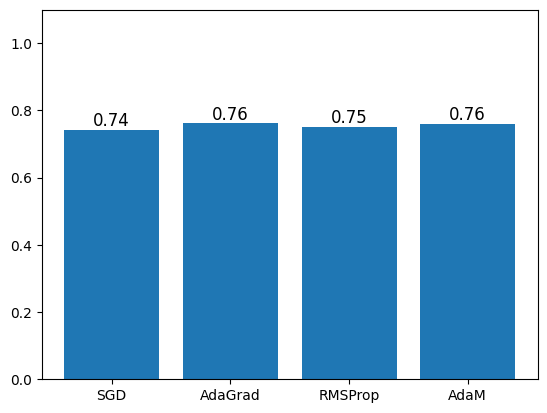

In [64]:
model_list = ['SGD', 'AdaGrad', 'RMSProp', 'AdaM']
result_list = [roc_auc_score(Y_test, sgd_pred, multi_class='ovr'),
               roc_auc_score(Y_test, adagrad_pred, multi_class='ovr'),
               roc_auc_score(Y_test, rmsprop_pred, multi_class='ovr'),
               roc_auc_score(Y_test, adam_pred, multi_class='ovr')
              ] 

bar = plt.bar(model_list, result_list)
for rect in bar:
    height = rect.get_height()
    plt.text(rect.get_x() + rect.get_width()/2.0, height, '%.2f' % height, ha='center', va='bottom', size = 12)
plt.ylim(0, 1.1)
plt.show()   

모든 옵티마이저의 성능이 유사하게 나왔습니다. 

옵티마이저 별 성능은 데이터셋에 따라 크게 달라질 수 있습니다.

본 실습에서는 범용성이 가장 뛰어나다고 알려진 AdaM을 사용하겠습니다.

---
## 7. 실습 데이터 불러오기 및 MLP 모델 적용
---
### 7.1 실습 데이터 불러오기
모든 전처리가 끝난 실습데이터를 불러오겠습니다.

In [65]:
df = pd.read_csv('./data/processed.csv') # df: dataframe의 줄임말
df.drop(columns = df.columns[0], axis = 1, inplace= True) # 데이터 순서를 표현하는 첫 열을 제거합니다.
display(df)

,Spacegroup,Formation Energy (eV),E Above Hull (eV),Band Gap (eV),Nsites,Density (gm/cc),Has Bandstructure,Crystal System
0,-0.9460,0.96830,1.1120,-1.5800,0.74170,2.61300,-2.0500,0.03653
1,-0.9460,-1.51900,-0.8633,1.1600,-0.55500,-0.63300,-2.0500,0.03653
2,-0.8640,0.07587,-0.4023,0.9644,-0.55500,1.21500,0.4863,1.16200
3,-0.7820,0.15210,0.9810,-1.0090,0.74170,1.06500,0.4863,-1.08900
4,-0.9460,-0.09820,0.8490,-0.2323,0.09344,-1.55700,0.4863,0.03653
...,...,...,...,...,...,...,...,...
324,-0.1285,0.51100,-1.4560,0.5635,-0.29570,0.49440,0.4863,1.16200
325,1.5060,0.51660,-1.4230,0.6226,-0.29570,0.68360,0.4863,1.16200
326,-0.9460,0.50600,1.3430,-1.0150,-0.72800,0.13280,0.4863,0.03653
327,-0.8640,-0.26680,0.6846,0.5664,-0.55500,-0.11304,0.4863,1.16200


---
### 7.2 학습 & 테스트 데이터 구분
7:3 의 비율로 학습 데이터와 테스트 데이터를 구분합니다.

이때 Crystal System 데이터를 정답 데이터로 분리합니다.

In [66]:
target_col = 'Crystal System'

y = df[target_col]
y = y.astype('category').cat.codes
X = df.drop(target_col, axis=1)
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3, random_state=random_seed)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(230, 7)
(99, 7)
(230,)
(99,)


---
### 7.3 원-핫 인코딩
정답데이터인 Crystal System에 원-핫 인코딩을 적용해야 합니다.

해당 데이터는 3개의 클래스를 가지고 있습니다.

이때, keras 라이브러리에서 제공하는 함수를 이용해 간편하게 적용할 수 있습니다.

In [67]:
from keras.utils import to_categorical
Y_train = to_categorical(Y_train)

---
### 7.3 MLP 모델 구성
토이 데이터셋보다 복잡한 데이터셋이므로, 은닉층 5개를 사용하겠습니다.

이진분류가 아니기 때문에, 마지막 출력층에 softmax 함수를 통과하도록 합니다.

또, Cross Entropy 손실함수를 사용합니다.

In [68]:
model = tf.keras.Sequential([
    Input(shape=X_train.shape[1]),
    tf.keras.layers.Dense(1024, activation = 'relu'),
    tf.keras.layers.Dense(512, activation = 'relu'),
    tf.keras.layers.Dense(256, activation = 'relu'),
    tf.keras.layers.Dense(128, activation = 'relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

lr = 0.001
model.compile(loss = 'categorical_crossentropy',
              optimizer = tf.keras.optimizers.Adam(learning_rate = lr),
              metrics=['accuracy']
)

---
### 7.4 모델 학습

In [69]:
history = model.fit(X_train, Y_train, epochs = 150, batch_size = 16, verbose = 2)

Epoch 1/150
15/15 - 1s - loss: 0.9315 - accuracy: 0.5304 - 1s/epoch - 77ms/step
Epoch 2/150
15/15 - 0s - loss: 0.7239 - accuracy: 0.6783 - 81ms/epoch - 5ms/step
Epoch 3/150
15/15 - 0s - loss: 0.6522 - accuracy: 0.6870 - 78ms/epoch - 5ms/step
Epoch 4/150
15/15 - 0s - loss: 0.6650 - accuracy: 0.6652 - 76ms/epoch - 5ms/step
Epoch 5/150
15/15 - 0s - loss: 0.5545 - accuracy: 0.7478 - 75ms/epoch - 5ms/step
Epoch 6/150
15/15 - 0s - loss: 0.4921 - accuracy: 0.7565 - 76ms/epoch - 5ms/step
Epoch 7/150
15/15 - 0s - loss: 0.4709 - accuracy: 0.7826 - 78ms/epoch - 5ms/step
Epoch 8/150
15/15 - 0s - loss: 0.4459 - accuracy: 0.8000 - 75ms/epoch - 5ms/step
Epoch 9/150
15/15 - 0s - loss: 0.4625 - accuracy: 0.7957 - 76ms/epoch - 5ms/step
Epoch 10/150
15/15 - 0s - loss: 0.5415 - accuracy: 0.7478 - 80ms/epoch - 5ms/step
Epoch 11/150
15/15 - 0s - loss: 0.3785 - accuracy: 0.8565 - 74ms/epoch - 5ms/step
Epoch 12/150
15/15 - 0s - loss: 0.3268 - accuracy: 0.8435 - 70ms/epoch - 5ms/step
Epoch 13/150
15/15 - 0s - 

---
### 7.5 분류 모델 성능 평가
다중 분류 문제이므로, 성능 지표 함수에 weighted 방법을 이용해 평가한다고 지정해주겠습니다.

In [70]:
def evaluation(prediction, Y_test, model_name="모델 이름"):
    print(model_name, "의 정답률은 %.2f%% 입니다." % (accuracy_score(prediction, Y_test) * 100))
    print(model_name, "의 정밀도는 %.2f 입니다." % precision_score(Y_test, prediction, average='weighted'))
    print(model_name, "의 재현율은 %.2f 입니다." % recall_score(Y_test, prediction, average='weighted'))
    print(model_name, "의 F1 점수는 %.2f 입니다." % f1_score(Y_test, prediction, average='weighted'))

In [71]:
pred = model.predict(X_test)
pred_classes=np.argmax(pred,axis=1)
evaluation(pred_classes, Y_test, model_name="MLP")

4/4 [==============================] - 0s 3ms/step
MLP 의 정답률은 76.77% 입니다.
MLP 의 정밀도는 0.77 입니다.
MLP 의 재현율은 0.77 입니다.
MLP 의 F1 점수는 0.77 입니다.
